# Walk-Forward Analysis — Hybrid Momentum Strategy

Este notebook importa `src/analysis/visualization.py` y genera las graficas
de resultados Walk-Forward. No simula nada: carga los CSVs de `results/`.

**Maquetacion academica**: Sin titulos superiores ni etiquetas flotantes.

```bash
python run_pipeline.py --mode walkforward
```

In [2]:
import os, sys, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_NOTEBOOK_DIR = os.path.abspath('')
_ROOT = os.path.dirname(_NOTEBOOK_DIR)
_SRC  = os.path.join(_ROOT, 'src')
if _SRC not in sys.path:
    sys.path.insert(0, _SRC)

from config import (
    FILE_WF_RESULTS, FILE_GRID_RESULTS,
    FECHA_TRAIN_END, FECHA_TEST_START, FECHA_INICIO_ANALISIS, DIR_FIGURES,
)
os.makedirs(DIR_FIGURES, exist_ok=True)

from analysis.visualization import (
    reconstruct_daily_equity, plot_equity_curve_with_split,
    plot_sharpe_scatter, plot_hyperparameter_distribution,
    plot_degradation_bar, plot_oos_parameter_sensitivity,
    load_walk_forward_results, load_grid_results,
    _get_price_wide, _run_engine_for_config, _top10pct_by_sharpe_test,
)

plt.rcParams.update({
    'font.family': 'sans-serif', 'axes.grid': True,
    'grid.alpha': 0.3, 'grid.linestyle': '--',
    'axes.spines.top': False, 'axes.spines.right': False, 'figure.dpi': 120,
})
COLOR_TRAIN = '#1f4e79'
COLOR_TEST  = '#e05c00'
SPLIT_DATE  = pd.Timestamp(FECHA_TEST_START)
print(f'Train ends : {FECHA_TRAIN_END}')
print(f'Test starts: {FECHA_TEST_START}')

Train ends : 2025-05-19
Test starts: 2025-05-20


In [3]:
df_wf   = load_walk_forward_results()
df_grid = load_grid_results()
if df_wf is not None and not df_wf.empty:
    cols = ['rank_train', 'Sharpe_Train', 'Sharpe_Test', 'Sharpe_Degradation_%']
    print(df_wf[[c for c in cols if c in df_wf.columns]].to_string(index=False))
else:
    print('AVISO: Ejecutar python run_pipeline.py --mode walkforward')

 Sharpe_Train  Sharpe_Test
        1.300       -0.025
        1.300       -0.025
        1.300       -0.025
        1.300       -0.025
        1.289        0.090
        1.289        0.090
        1.289        0.090
        1.289        0.090
        1.273       -0.191
        1.273       -0.191
        1.273       -0.191
        1.273       -0.191
        1.262        0.367
        1.262        0.367
        1.262        0.367
        1.262        0.367
        1.254       -0.025
        1.254       -0.025
        1.254       -0.025
        1.254       -0.025
        1.246        0.087
        1.246        0.087
        1.246        0.087
        1.246        0.087
        1.236       -0.056
        1.236       -0.056
        1.236       -0.056
        1.236       -0.056
        1.226       -0.025
        1.226       -0.025
        1.226       -0.025
        1.226       -0.025
        1.219       -0.312
        1.219       -0.312
        1.219       -0.312
        1.219       -0.312
 

## Grafica 1 — Curva de Equidad Diaria Real del Ganador

  [visualization] Guardado -> /workspaces/hybrid-momentum-anomaly-detection/results/figures/wf_01_equity_curve_winner_daily.png


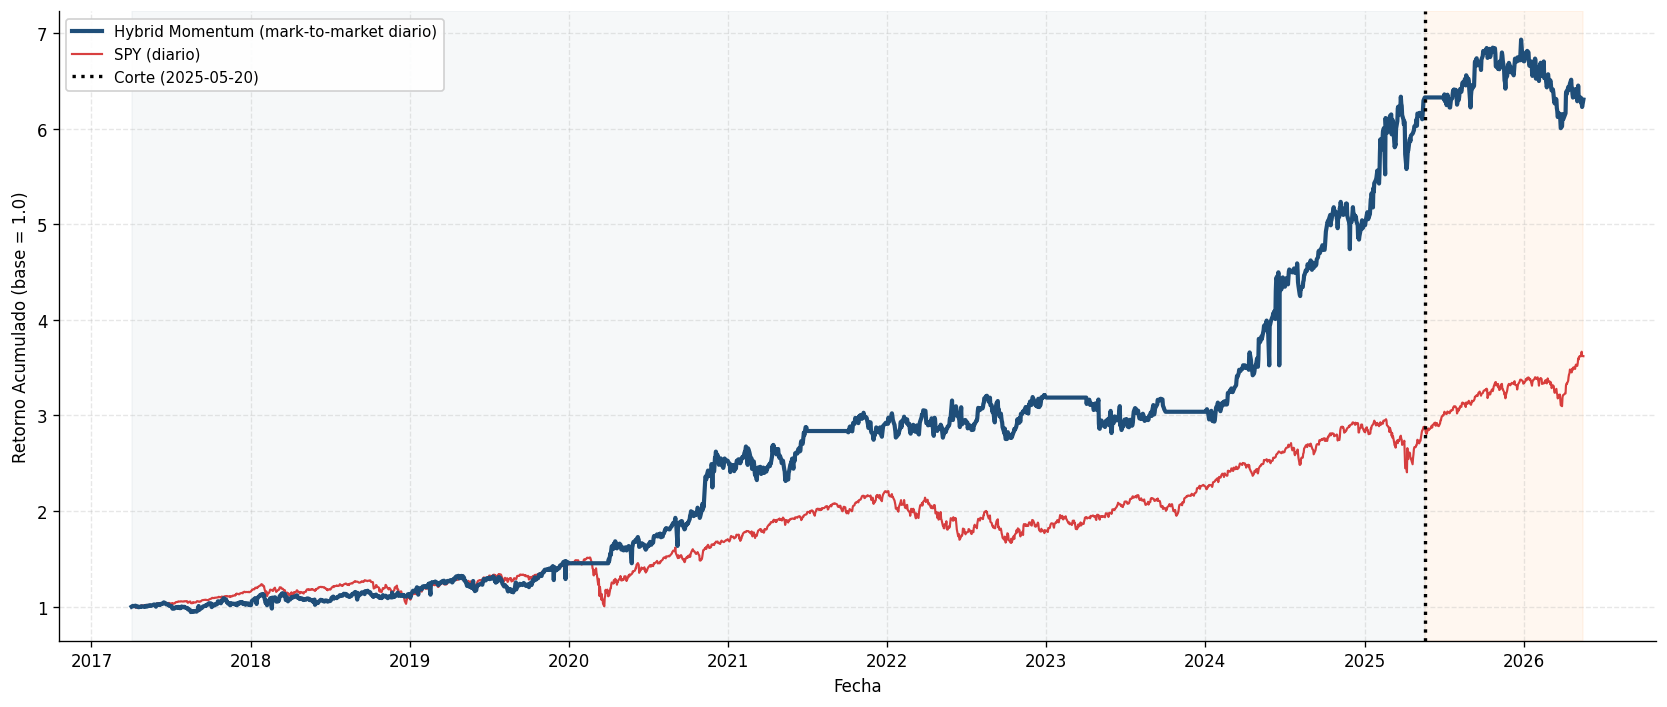

In [4]:
if df_wf is not None and not df_wf.empty:
    plot_equity_curve_with_split(rank=1, wf_results_df=df_wf,
        save=True, filename='wf_01_equity_curve_winner_daily.png')

## Grafica 2 — Scatter: Sharpe Train vs Sharpe Test

  [visualization] Guardado -> /workspaces/hybrid-momentum-anomaly-detection/results/figures/wf_02_sharpe_scatter.png


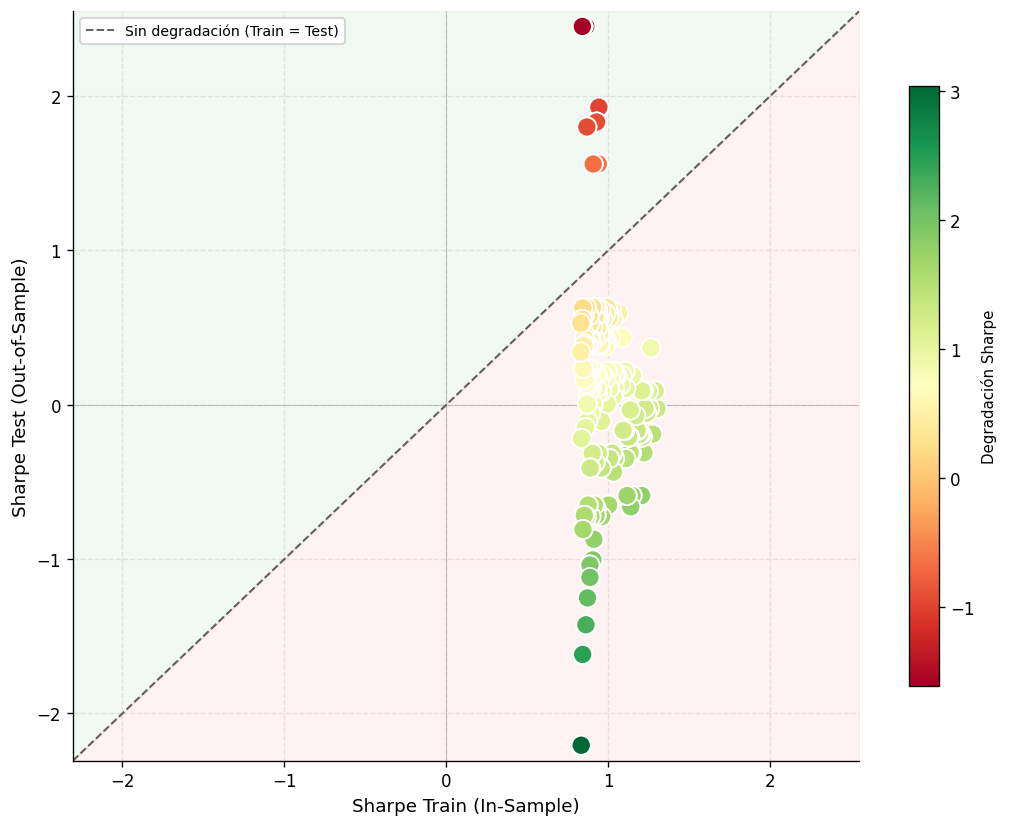

In [5]:
if df_wf is not None and not df_wf.empty:
    plot_sharpe_scatter(wf_df=df_wf, save=True, filename='wf_02_sharpe_scatter.png')

## Grafica 3 — Barras Sharpe Train vs Test por Configuracion

[visualization] Sección 6 — 640 configs válidas; mostrando top/bottom 25 por Sharpe_Train.
  [visualization] Guardado -> /workspaces/hybrid-momentum-anomaly-detection/results/figures/wf_03_degradation_bar.png


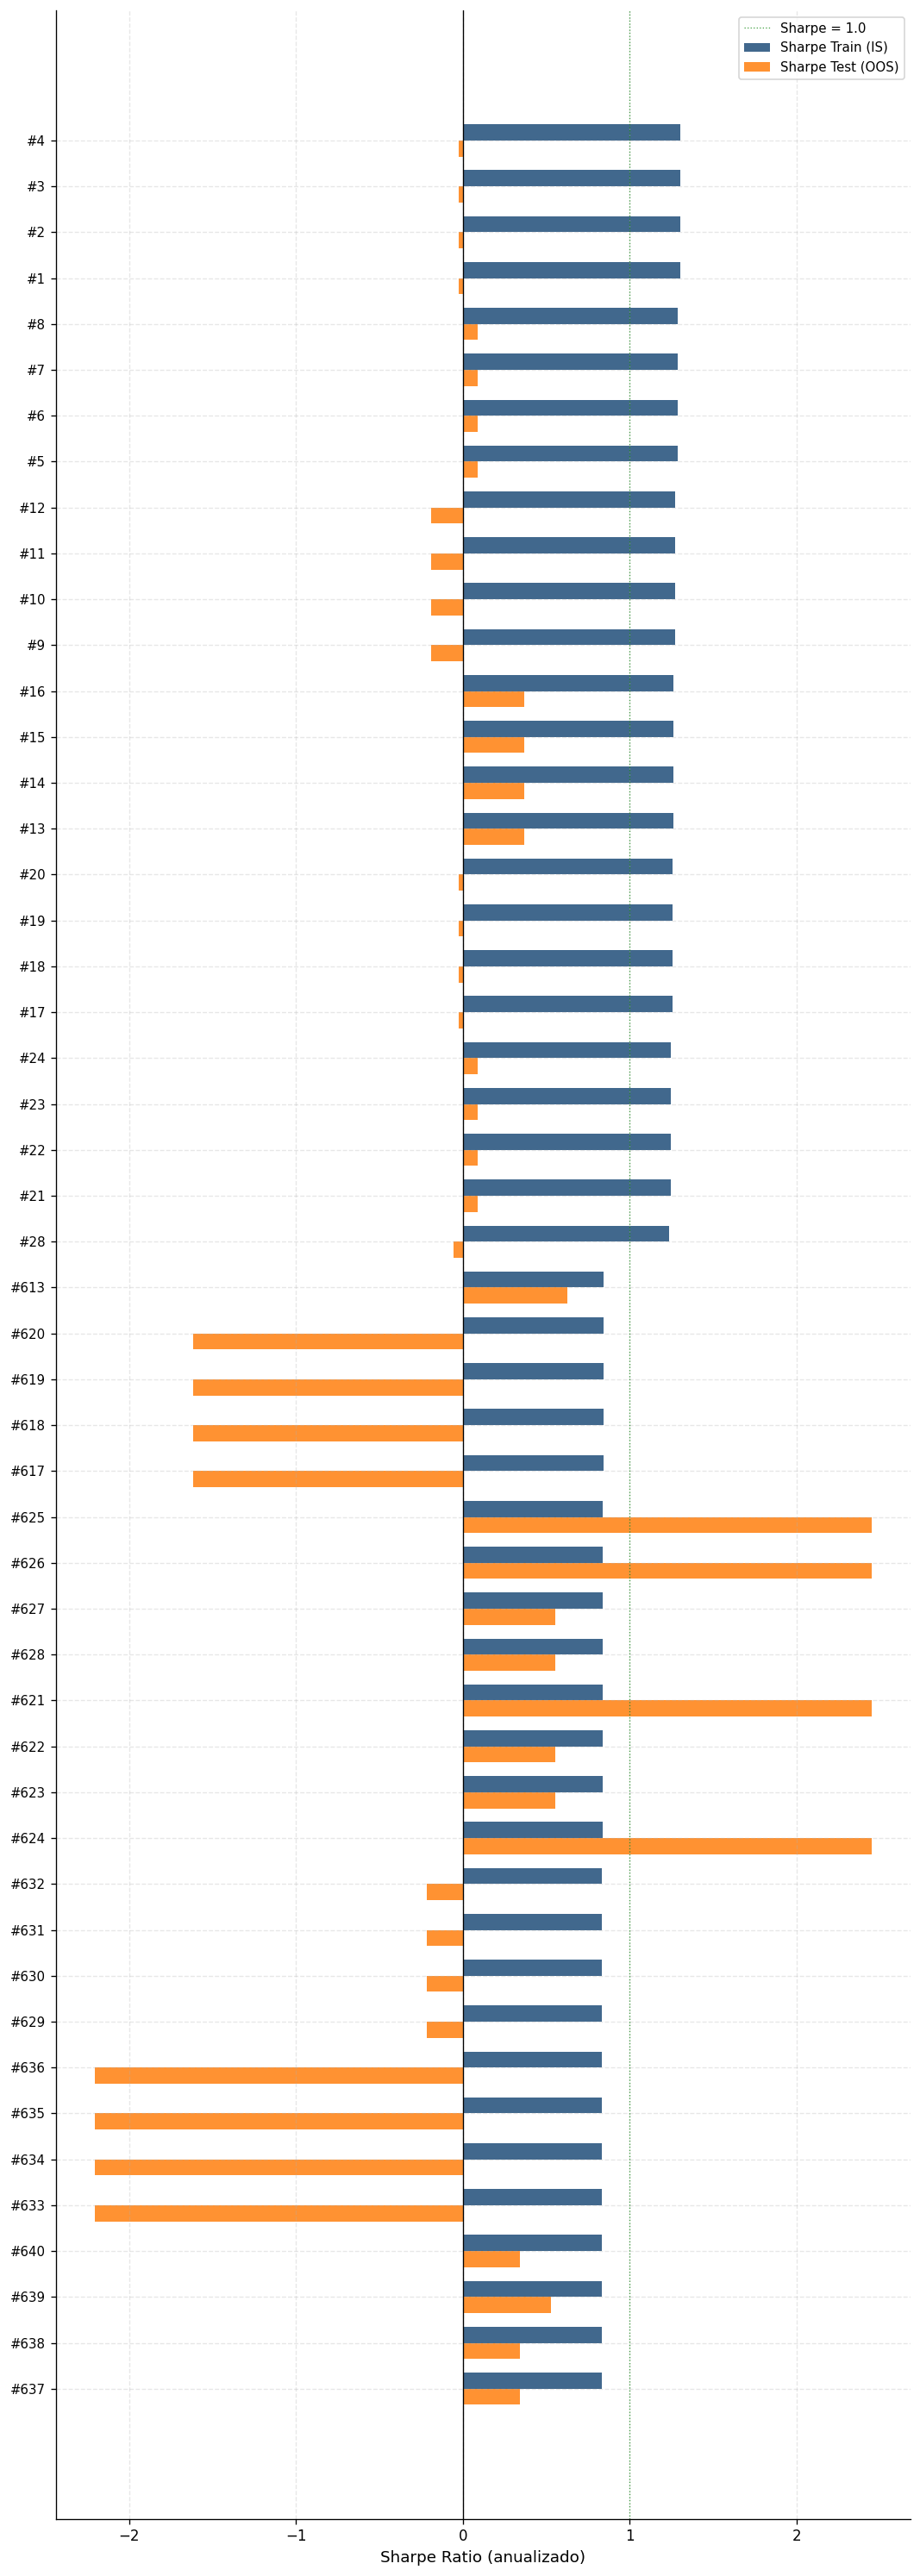

In [6]:
if df_wf is not None and not df_wf.empty:
    plot_degradation_bar(wf_df=df_wf, save=True, filename='wf_03_degradation_bar.png')

## Grafica 4 — Distribucion de Hiperparametros (Top 10 % por Sharpe_Test)

Solo las configuraciones con mayor Sharpe Out-of-Sample.

  [_top10pct_by_sharpe_test] Umbral Sharpe_Test >= 0.6140: 72/640 estrategias retenidas.
Top 10 % por Sharpe_Test: 72 configuraciones
  [_top10pct_by_sharpe_IS] Umbral Sharpe >= 0.8300: 644/6400 estrategias retenidas.
[visualization] Sección 5 — Top 10 % Grid IS por Sharpe (In-Sample): N=644
[visualization] Sección 5 — Coherencia de conteos (n_elite=644):
  [OK] top_n: conteos=644, NaN=0, total=644
  [OK] rebalance_freq: conteos=644, NaN=0, total=644
  [OK] anomaly_lookback_days: conteos=644, NaN=0, total=644
  [OK] momentum_signal: conteos=644, NaN=0, total=644
  [OK] active_cluster: conteos=644, NaN=0, total=644
  [OK] rank_weighted: conteos=644, NaN=0, total=644
  [OK] min_portfolio_size: conteos=644, NaN=0, total=644
  -> Todos los parámetros son matemáticamente coherentes.
  [visualization] Guardado -> /workspaces/hybrid-momentum-anomaly-detection/results/figures/wf_04_hyperparameter_distribution_oos.png  (Top 10 % Grid IS por Sharpe (In-Sample), N=644)


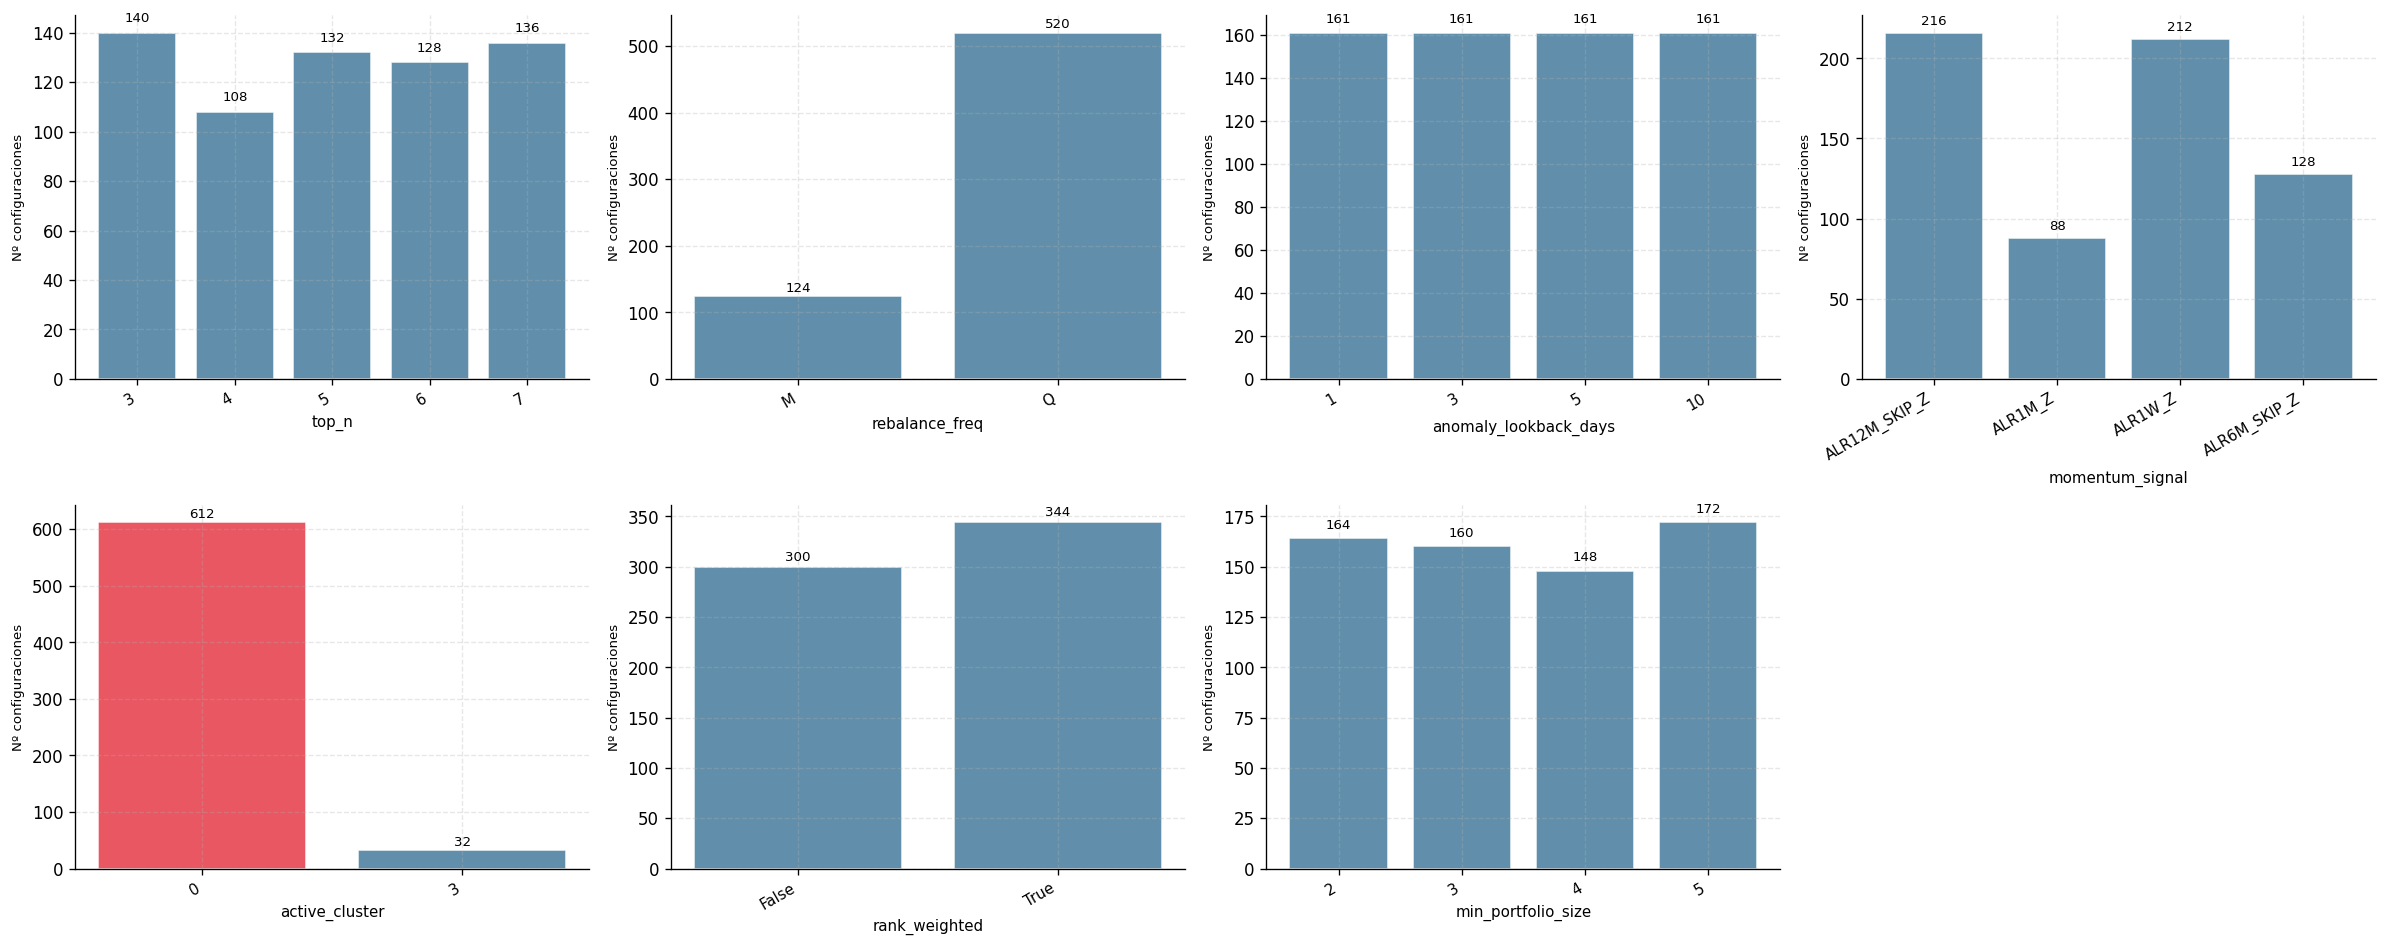

In [7]:
if df_wf is not None and not df_wf.empty:
    elite = _top10pct_by_sharpe_test(df_wf)
    print(f'Top 10 % por Sharpe_Test: {len(elite)} configuraciones')
    plot_hyperparameter_distribution(wf_df=df_wf, save=True,
        filename='wf_04_hyperparameter_distribution_oos.png')

## Grafica 5 — Distribucion de Sharpe del Grid Search completo

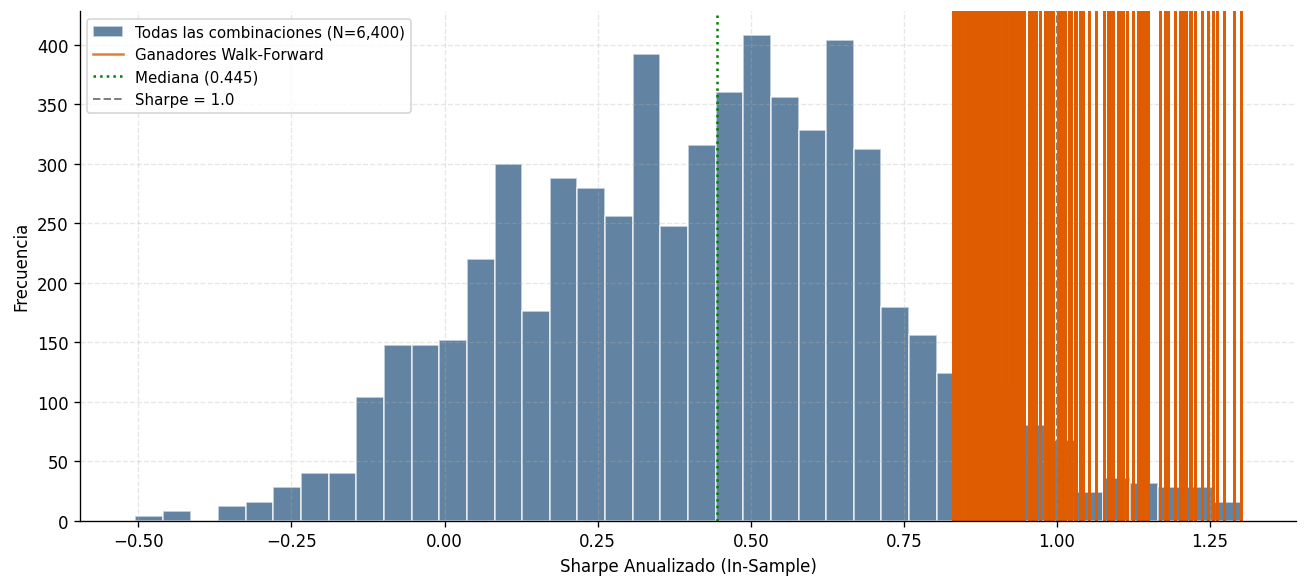

Guardado: /workspaces/hybrid-momentum-anomaly-detection/results/figures/wf_05_sharpe_distribution_grid.png


In [8]:
if df_grid is not None and not df_grid.empty and 'Sharpe' in df_grid.columns:
    sharpes = df_grid['Sharpe'].dropna()
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.hist(sharpes, bins=40, color=COLOR_TRAIN, alpha=0.7, edgecolor='white',
            label=f'Todas las combinaciones (N={len(sharpes):,})')
    if df_wf is not None and 'Sharpe_Train' in df_wf.columns:
        for i, s in enumerate(df_wf['Sharpe_Train'].dropna()):
            ax.axvline(x=s, color=COLOR_TEST, lw=1.5, alpha=0.8,
                       label='Ganadores Walk-Forward' if i == 0 else '_nolegend_')
    ax.axvline(x=sharpes.median(), color='green', lw=1.5, ls=':',
               label=f'Mediana ({sharpes.median():.3f})')
    ax.axvline(x=1.0, color='gray', lw=1.2, ls='--', label='Sharpe = 1.0')
    ax.set_xlabel('Sharpe Anualizado (In-Sample)', fontsize=10)
    ax.set_ylabel('Frecuencia', fontsize=10)
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    out = os.path.join(DIR_FIGURES, 'wf_05_sharpe_distribution_grid.png')
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Guardado: {out}')

## Grafica 6 — Sensibilidad OOS por Hiperparametro (Top 10 % Sharpe_Test)

> Puede tardar 1-2 minutos.

[visualization] Pool OOS para sensibilidad: 640 configuraciones
[visualization] Reconstruyendo curvas diarias OOS...
  [visualization] 640/640 curvas reconstruidas (0 fallidas).
  [visualization] Guardado -> /workspaces/hybrid-momentum-anomaly-detection/results/figures/wf_06_oos_parameter_sensitivity_top10pct.png


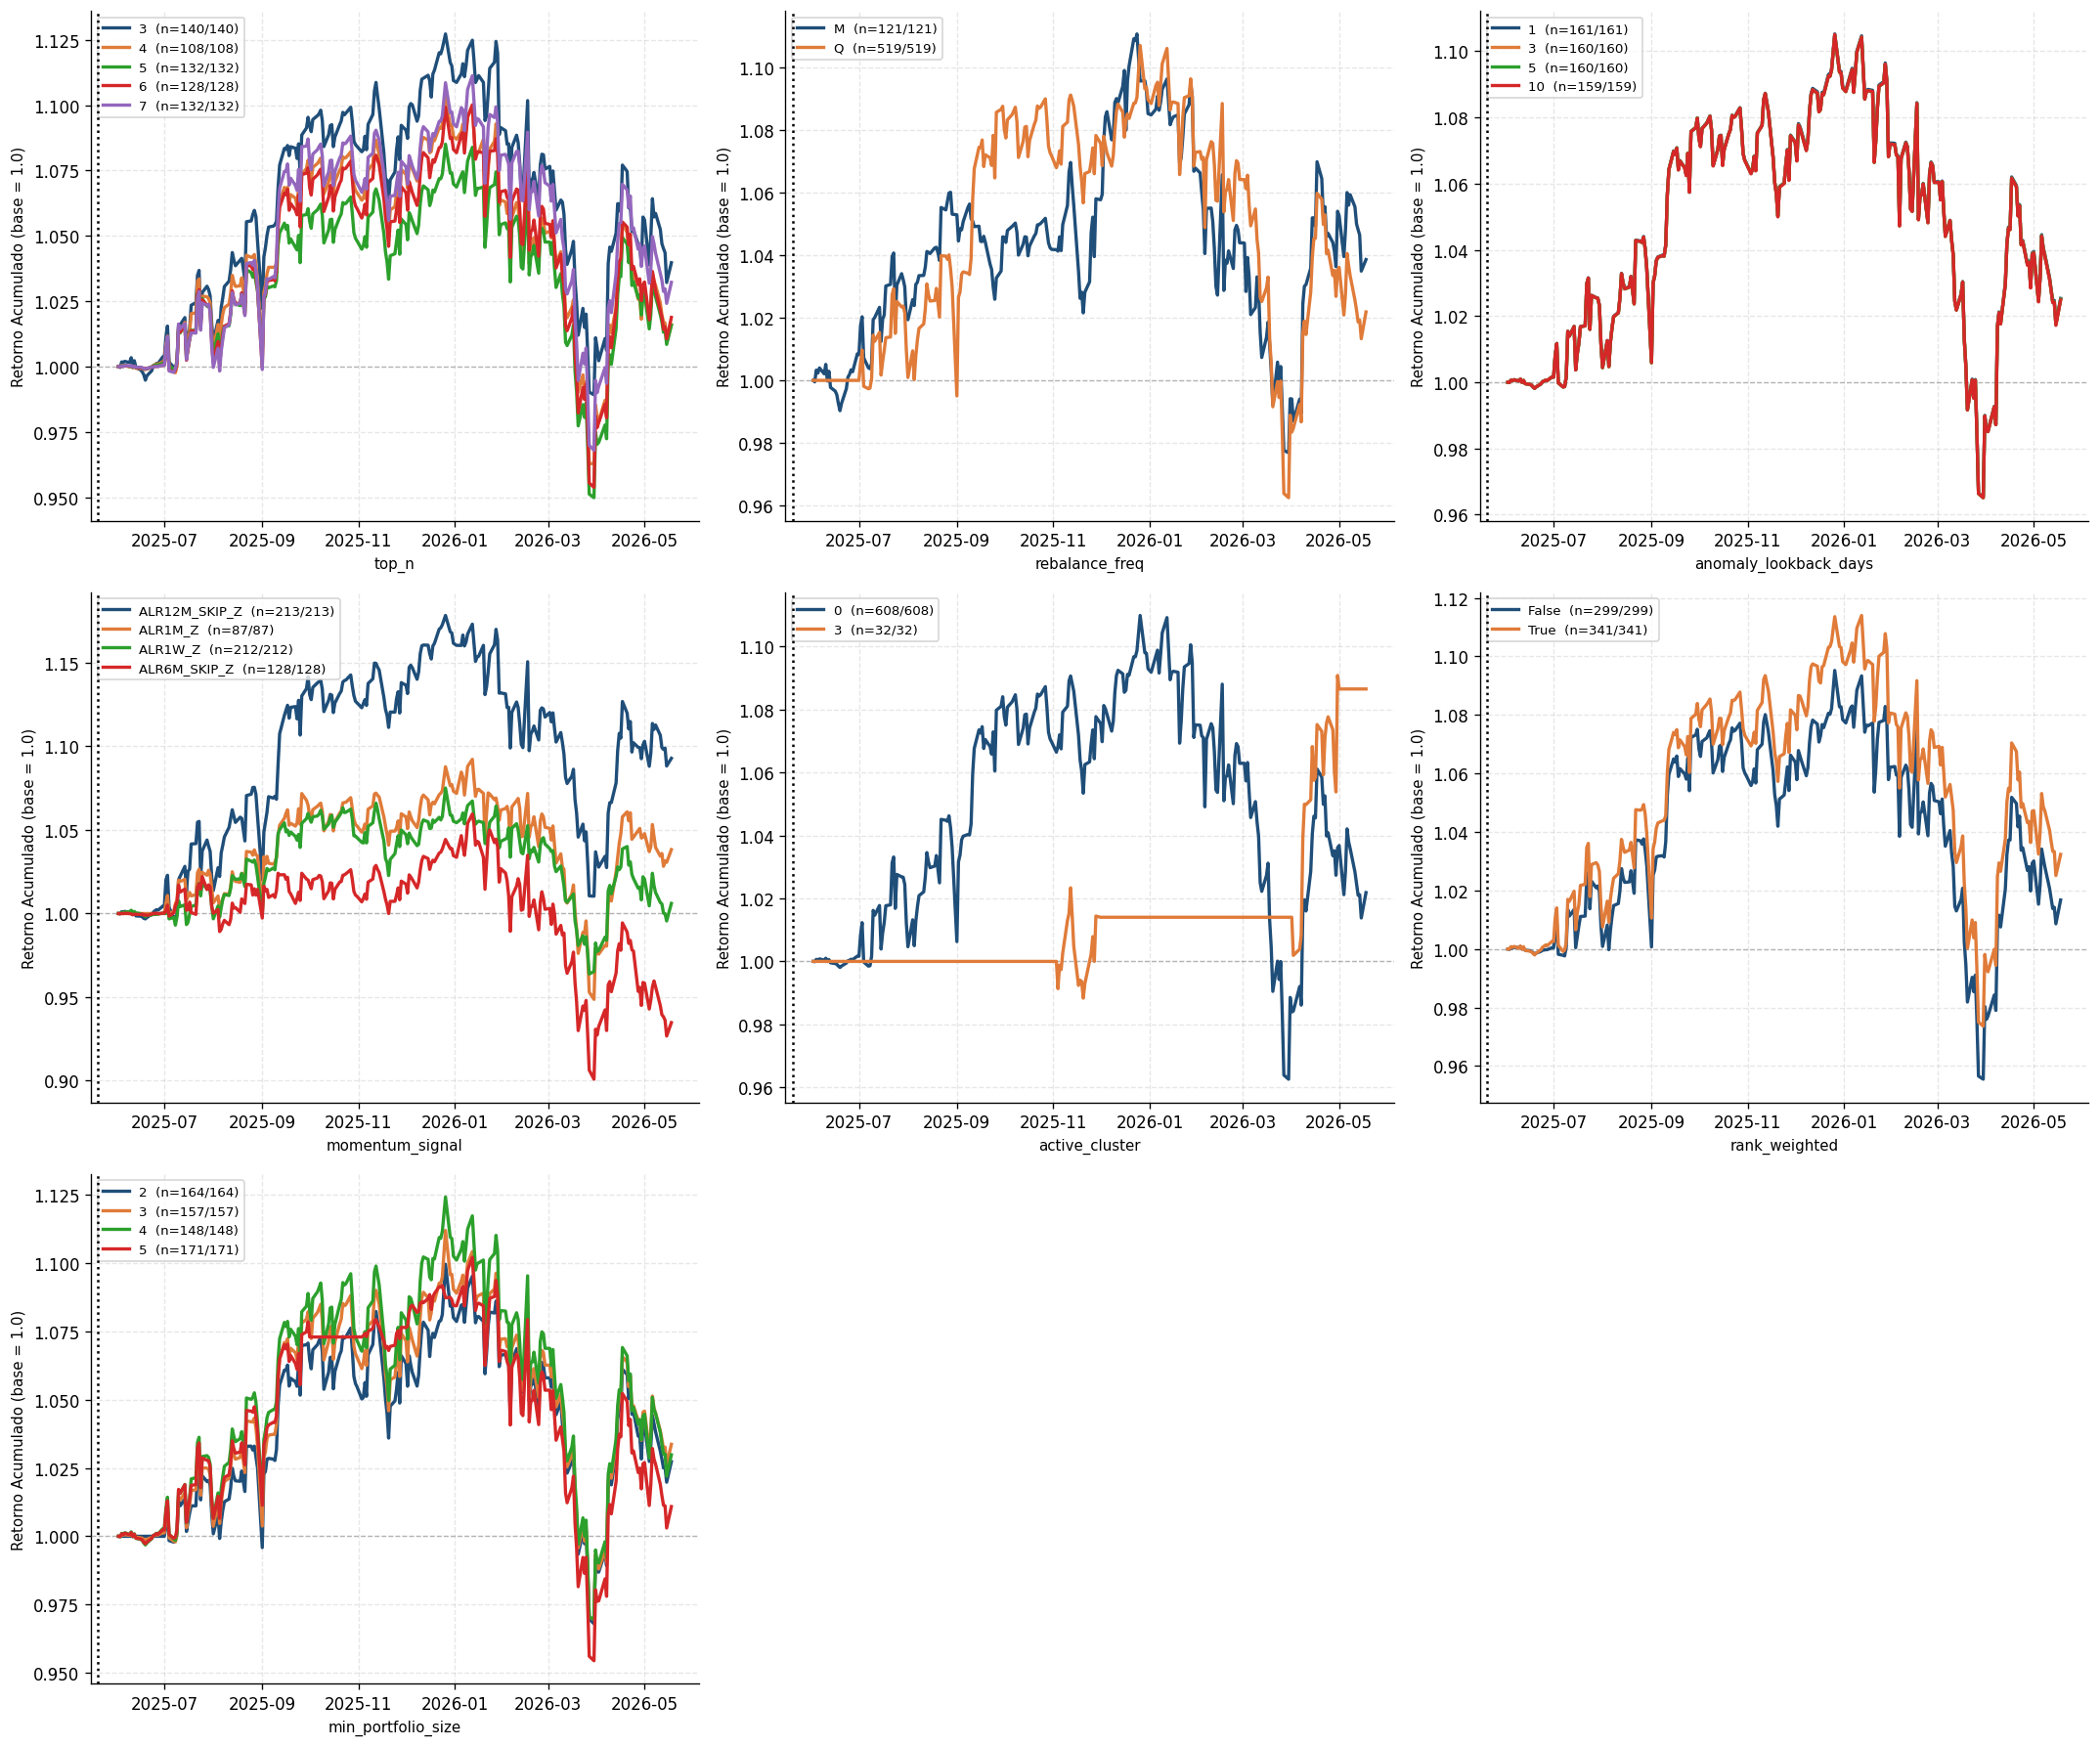

In [9]:
if df_wf is not None and not df_wf.empty:
    plot_oos_parameter_sensitivity(wf_df=df_wf, save=True,
        filename='wf_06_oos_parameter_sensitivity_top10pct.png')

## Tabla Resumen Walk-Forward

In [10]:
if df_wf is not None and not df_wf.empty:
    summary_cols = ['rank_train','Sharpe_Train','Sharpe_Test','Sharpe_Degradation_%',
                    'CAGR_Train_%','CAGR_Test_%','MaxDD_Train_%','MaxDD_Test_%']
    avail = [c for c in summary_cols if c in df_wf.columns]
    try:
        styled = (
            df_wf[avail].style
            .format({'Sharpe_Train':'{:.3f}','Sharpe_Test':'{:.3f}',
                     'Sharpe_Degradation_%':'{:+.1f}%','CAGR_Train_%':'{:.1f}%',
                     'CAGR_Test_%':'{:.1f}%','MaxDD_Train_%':'{:.1f}%',
                     'MaxDD_Test_%':'{:.1f}%'}, na_rep='N/A')
            .background_gradient(subset=['Sharpe_Test'], cmap='RdYlGn')
            .background_gradient(subset=['Sharpe_Degradation_%'], cmap='RdYlGn_r')
        )
        display(styled)
    except Exception:
        print(df_wf[avail].to_string(index=False))
    if 'Sharpe_Test' in df_wf.columns:
        vt = df_wf['Sharpe_Test'].dropna()
        print(f'Sharpe Test: media={vt.mean():.3f} | max={vt.max():.3f}')
    if 'Sharpe_Degradation_%' in df_wf.columns:
        vd = df_wf['Sharpe_Degradation_%'].dropna()
        print(f'Degradacion media: {vd.mean():+.1f}% | {(vd>0).sum()}/{len(vd)} configs mejoran')

KeyError: "None of [Index(['Sharpe_Degradation_%'], dtype='str')] are in the [columns]"

Sharpe Test: media=0.119 | max=2.449


In [11]:
import glob
figuras = sorted(glob.glob(os.path.join(DIR_FIGURES, 'wf_*.png')))
print(f'Figuras en {DIR_FIGURES}:')
for f in figuras:
    print(f'  {os.path.basename(f):55s} {os.path.getsize(f)/1024:6.1f} KB')

Figuras en /workspaces/hybrid-momentum-anomaly-detection/results/figures:
  wf_01_equity_curve_winner_daily.png                      150.0 KB
  wf_02_sharpe_scatter.png                                 117.7 KB
  wf_03_degradation_bar.png                                189.5 KB
  wf_04_hyperparameter_distribution_oos.png                174.6 KB
  wf_05_sharpe_distribution_grid.png                        76.6 KB
  wf_06_oos_parameter_sensitivity_top10pct.png             842.0 KB
